<a href="https://colab.research.google.com/github/Prasanthi-Peram/AIFA/blob/main/RL__Assignment_23IM10027_MDP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the MDP

A note on indexing: In Python, indexing starts from 0. So, when we define `actions = [0, 1, 2]`, these correspond to what might intuitively be called Action 1, Action 2, and Action 3 respectively. Similarly for states.

In [ ]:
states = [0, 1]
actions = [0, 1, 2]

gamma = 0.9

# P[a, s, s']
P = np.array([
    [[0.3, 0.7],
     [0.8, 0.2]],

    [[0.9, 0.1],
     [0.25, 0.75]],

    [[0.6, 0.4],
     [0.5, 0.5]]
])

# R[a, s, s']
R = np.array([
    [[2, 1],
     [1, 2]],

    [[1, 3],
     [4, 3]],

    [[2, 2],
     [1, 1]]
])

In [ ]:
print("Transition probabilities:")
print(P)

print("\nChecking that probabilities add up to 1:")

for a in actions:
    for s in states:
        print(
            "Action", a,
            "State", s,
            "sum =", P[a, s].sum()
        )

Transition probabilities:
[[[0.3  0.7 ]
  [0.8  0.2 ]]

 [[0.9  0.1 ]
  [0.25 0.75]]

 [[0.6  0.4 ]
  [0.5  0.5 ]]]

Checking that probabilities add up to 1:
Action 0 State 0 sum = 1.0
Action 0 State 1 sum = 1.0
Action 1 State 0 sum = 1.0
Action 1 State 1 sum = 1.0
Action 2 State 0 sum = 1.0
Action 2 State 1 sum = 1.0


# Setting up the MDP solver
#
# This class contains the main calculations used in the assignment.
# Containing Policy Evaluation, Policy Improvement, Policy Iteration
# and Value Iteration together so that all of them use the same MDP.

In [ ]:
class finite_mdp_solver:

    def __init__(self, nActions, nSteps, nStates,
                 states, actions, reward_matrix,
                 tr_matrix, gamma):

        self.nActions = nActions
        self.nSteps = nSteps
        self.nStates = nStates
        self.reward_matrix = reward_matrix
        self.tr_matrix = tr_matrix
        self.states = states
        self.actions = actions
        self.gamma = gamma

    def initPolicy(self):

        policy = np.zeros(self.nStates, dtype=int)

        for i in range(self.nStates):
            policy[i] = np.random.randint(
                1, self.nActions + 1
            )

        return policy

    def state_value_function(self, state, policy, current_value):

        value = 0

        action = int(policy[state - 1])

        for s in self.states:

            value += self.tr_matrix[
                action - 1, state - 1, s - 1
            ] * (
                self.reward_matrix[
                    action - 1, state - 1, s - 1
                ]
                + self.gamma * current_value[s - 1]
            )

        return value

    def action_value_function(self, state, action, current_value):

        value = 0

        for s in self.states:

            value += self.tr_matrix[
                action - 1, state - 1, s - 1
            ] * (
                self.reward_matrix[
                    action - 1, state - 1, s - 1
                ]
                + self.gamma * current_value[s - 1]
            )

        return value

    def policy_evaluation(self, policy, theta=0.000001):

        current_value = np.zeros(self.nStates)

        value_history = []
        delta_history = []

        while True:

            delta = 0
            new_value = current_value.copy()

            for state in self.states:

                value = self.state_value_function(
                    state,
                    policy,
                    current_value
                )

                new_value[state - 1] = value

                delta = max(
                    delta,
                    abs(current_value[state - 1] - value)
                )

            current_value = new_value

            value_history.append(current_value.copy())
            delta_history.append(delta)

            if delta < theta:
                break

        return current_value, value_history, delta_history

    def policy_improvement(self, current_value):

        policy = np.zeros(self.nStates, dtype=int)

        for state in self.states:

            action_values = []

            for action in self.actions:

                value = self.action_value_function(
                    state,
                    action,
                    current_value
                )

                action_values.append(value)

            policy[state - 1] = np.argmax(action_values) + 1

        return policy

    def policy_iteration(self, theta=0.000001):

        policy = self.initPolicy()

        policy_history = []
        value_history = []

        while True:

            old_policy = policy.copy()

            current_value, values, deltas = self.policy_evaluation(
                policy,
                theta
            )

            value_history.append(current_value.copy())

            policy = self.policy_improvement(
                current_value
            )

            policy_history.append(policy.copy())

            print(
                "Old policy:", old_policy,
                " New policy:", policy
            )

            if np.array_equal(policy, old_policy):
                break

        return policy, current_value, policy_history, value_history

    def value_iteration(self, theta=0.000001):

        current_value = np.zeros(self.nStates)

        value_history = []
        delta_history = []

        while True:

            delta = 0
            new_value = current_value.copy()

            for state in self.states:

                action_values = []

                for action in self.actions:

                    value = self.action_value_function(
                        state,
                        action,
                        current_value
                    )

                    action_values.append(value)

                new_value[state - 1] = max(action_values)

                delta = max(
                    delta,
                    abs(
                        current_value[state - 1]
                        - new_value[state - 1]
                    )
                )

            current_value = new_value

            value_history.append(current_value.copy())
            delta_history.append(delta)

            if delta < theta:
                break

        optimal_policy = self.policy_improvement(
            current_value
        )

        return (
            optimal_policy,
            current_value,
            value_history,
            delta_history
        )

# Create the solver

In [ ]:
nStates = len(states)
nActions = len(actions)
tr_matrix = P
reward_matrix = R

solver = finite_mdp_solver(
    nActions,
    1000,
    nStates,
    states,
    actions,
    reward_matrix,
    tr_matrix,
    gamma
)

# Policy Evaluation

In [ ]:
print("==============================")
print("Policy Evaluation")
print("==============================")

policy = np.array([1, 1])

value, value_history, delta_history = solver.policy_evaluation(
    policy
)

print("\nPolicy:", policy)
print("Value function:", value)
print("Number of iterations:", len(value_history))

Policy Evaluation

Policy: [1 1]
Value function: [12.56550891 12.49654339]
Number of iterations: 135


In [ ]:
print("\nAll iterations:")

for i, values in enumerate(value_history):

    print(i + 1, values)


All iterations:
1 [1.3 1.2]
2 [2.407 2.352]
3 [3.43165 3.3564 ]
4 [4.3410775 4.27494  ]
5 [5.16530313 5.095065  ]
6 [5.90452279 5.83612995]
7 [6.57098302 6.5017598 ]
8 [7.17027409 7.10142454]
9 [7.70987147 7.64085376]
10 [8.19540317 8.12646113]
11 [8.63242937 8.56345328]
12 [9.0257315  8.95677074]
13 [9.37971307 9.31074541]
14 [9.69829214 9.62932758]
15 [9.98501525 9.9160493 ]
16 [10.24306518 10.17409986]
17 [10.47531051 10.4063449 ]
18 [10.68433113 10.61536565]
19 [10.87244976 10.80348423]
20 [11.0417565  10.97279099]
21 [11.19413258 11.12516706]
22 [11.33127104 11.26230553]
23 [11.45469566 11.38573015]
24 [11.56577782 11.4968123 ]
25 [11.66575176 11.59678625]
26 [11.75572831 11.68676279]
27 [11.8367072  11.76774169]
28 [11.90958821 11.84062269]
29 [11.97518111 11.90621559]
30 [12.03421472 11.96524921]
31 [12.08734498 12.01837946]
32 [12.1351622  12.06619669]
33 [12.17819771 12.10923219]
34 [12.21692966 12.14796414]
35 [12.25178842 12.1828229 ]
36 [12.2831613  12.21419578]
37 [12.311

# Policy Evaluation convergence plot

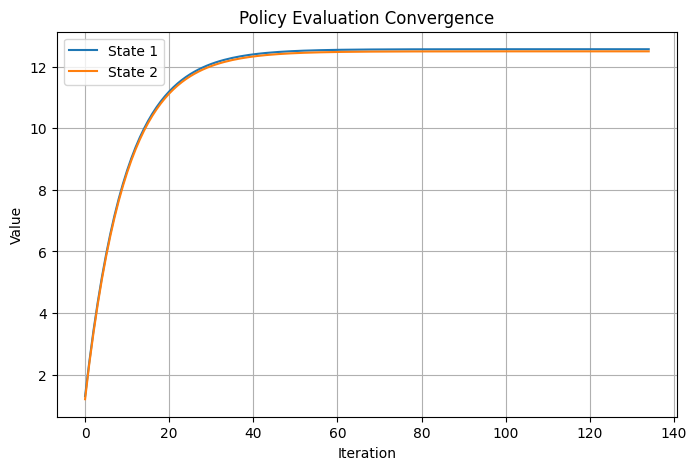

In [ ]:
value_history_array = np.array(value_history)

plt.figure(figsize=(8, 5))

plt.plot(
    value_history_array[:, 0],
    label="State 1"
)

plt.plot(
    value_history_array[:, 1],
    label="State 2"
)

plt.xlabel("Iteration")
plt.ylabel("Value")
plt.title("Policy Evaluation Convergence")

plt.legend()
plt.grid()

plt.show()

# Policy Evaluation Δ plot

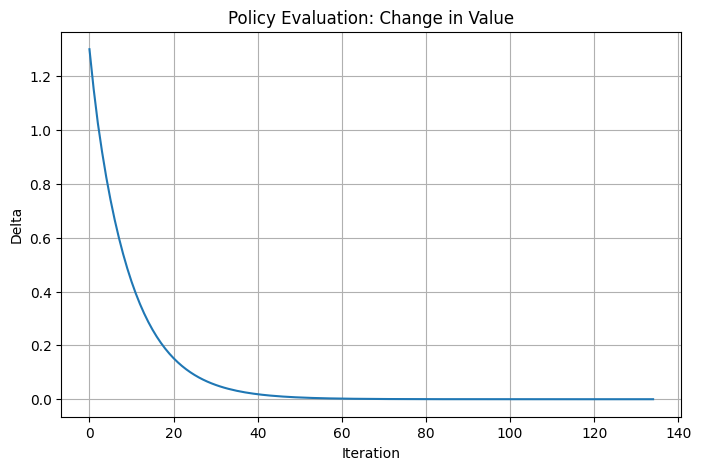

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(delta_history)

plt.xlabel("Iteration")
plt.ylabel("Delta")
plt.title("Policy Evaluation: Change in Value")

plt.grid()

plt.show()

# Policy Improvement

In [ ]:
print("==============================")
print("Policy Improvement")
print("==============================")

q_values = np.zeros((nStates, nActions))

for state in states:

    for action in actions:

        q_values[state - 1, action - 1] = (
            solver.action_value_function(
                state,
                action,
                value
            )
        )

print("\nQ-values:")
print(q_values)

new_policy = solver.policy_improvement(value)

print("\nOld policy:", policy)
print("New policy:", new_policy)

Policy Improvement

Q-values:
[[12.56550974 12.50275112 13.28413043]
 [12.49654422 14.51240629 12.27792353]]

Old policy: [1 1]
New policy: [1 3]


# Policy Iteration

In [ ]:
print("==============================")
print("Policy Iteration")
print("==============================")

optimal_policy_pi, optimal_value_pi, policy_history, pi_value_history = (
    solver.policy_iteration()
)

print("\nFinal policy from Policy Iteration:")
print(optimal_policy_pi)

print("\nFinal value function:")
print(optimal_value_pi)

Policy Iteration
Old policy: [1 1]  New policy: [1 3]
Old policy: [1 3]  New policy: [1 3]

Final policy from Policy Iteration:
[1 3]

Final value function:
[11.39829677 11.14405949]


# Value Iteration

In [ ]:
print("==============================")
print("Value Iteration")
print("==============================")

optimal_policy_vi, optimal_value_vi, vi_value_history, vi_delta_history = (
    solver.value_iteration()
)

print("\nOptimal policy from Value Iteration:")
print(optimal_policy_vi)

print("\nOptimal value function:")
print(optimal_value_vi)

print("\nNumber of iterations:")
print(len(vi_value_history))

Value Iteration

Optimal policy from Value Iteration:
[1 3]

Optimal value function:
[26.56933426 28.39415178]

Number of iterations:
142


# Show Value Iteration iterations

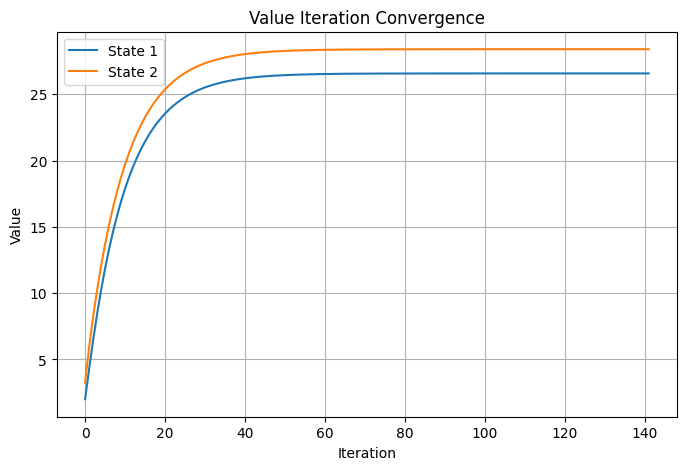

In [ ]:
vi_value_history_array = np.array(vi_value_history)

plt.figure(figsize=(8, 5))

plt.plot(
    vi_value_history_array[:, 0],
    label="State 1"
)

plt.plot(
    vi_value_history_array[:, 1],
    label="State 2"
)

plt.xlabel("Iteration")
plt.ylabel("Value")
plt.title("Value Iteration Convergence")

plt.legend()
plt.grid()

plt.show()

# Value Iteration convergence plot

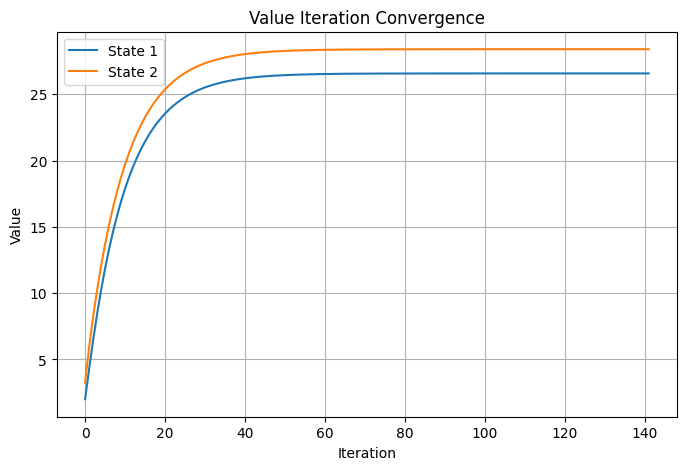

In [ ]:
vi_value_history_array = np.array(vi_value_history)

plt.figure(figsize=(8, 5))

plt.plot(
    vi_value_history_array[:, 0],
    label="State 1"
)

plt.plot(
    vi_value_history_array[:, 1],
    label="State 2"
)

plt.xlabel("Iteration")
plt.ylabel("Value")
plt.title("Value Iteration Convergence")

plt.legend()
plt.grid()

plt.show()

# Value Iteration Δ plot

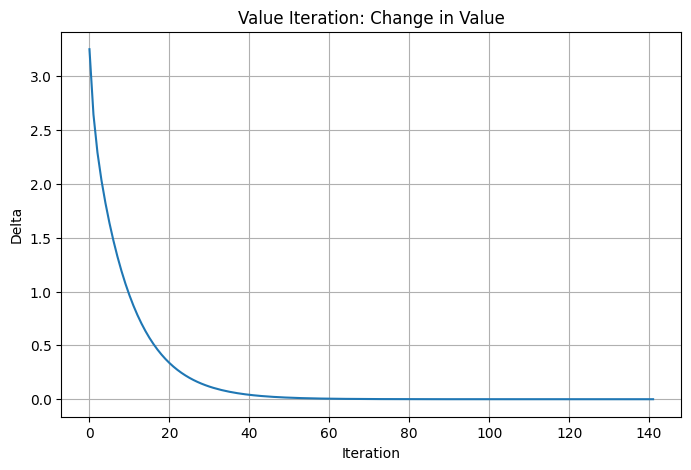

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(vi_delta_history)

plt.xlabel("Iteration")
plt.ylabel("Delta")
plt.title("Value Iteration: Change in Value")

plt.grid()

plt.show()

# Final Comparison

In [ ]:
print("===================================")
print("Final Comparison")
print("===================================")

print("\nPolicy Iteration")
print("Policy:", optimal_policy_pi)
print("Value:", optimal_value_pi)

print("\nValue Iteration")
print("Policy:", optimal_policy_vi)
print("Value:", optimal_value_vi)

Final Comparison

Policy Iteration
Policy: [1 3]
Value: [11.39829677 11.14405949]

Value Iteration
Policy: [1 3]
Value: [26.56933426 28.39415178]
